# 03 - BAF Predictive Model Benchmarks

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

if KAGGLE:
    os.environ["THESIS_QUICK_RUN"] = "0"
    os.environ["THESIS_SYNTHETIC_FALLBACK"] = "0"
    if not KAGGLE_PROJECT_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(KAGGLE_PROJECT_DIR)],
            check=True,
        )

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = [path for path in base.glob("**/configs") if path.is_dir()]
            if matches:
                return matches[0].parent
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "0") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "0") == "1"
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"

GIT_COMMIT = None
if KAGGLE:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "synthetic_fallback": ALLOW_SYNTHETIC_FALLBACK,
    "kaggle": KAGGLE,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': '39f54bc584f9795806ace8d2517e8e7ac4497d27', 'quick_run': False, 'synthetic_fallback': False, 'kaggle': True}


## Thiết lập

- PR-AUC is the primary metric.
- F2 is the default operating-threshold objective.
- Full mode repeats the benchmark over three independent seeds.
- Quick mode is an explicit smoke test, not thesis evidence.

In [2]:
from src.experiment import run_repeated_predictive_benchmarks

output_dir = OUTPUT_BASE / "03_baf_model_benchmarks"
result = run_repeated_predictive_benchmarks(
    PROJECT_ROOT / "configs/baf.yaml",
    output_dir=output_dir,
    model_names=("mlp", "tabular_resnet", "tree"),
    quick_run=QUICK_RUN,
    synthetic_fallback=ALLOW_SYNTHETIC_FALLBACK,
)
metrics = result["metrics"]
summary = result["summary"]
print({"data_sources": result["data_sources"], "seeds": result["seeds"], "output_dir": str(output_dir)})
display(summary.round(4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

{'data_sources': ['real'], 'seeds': [42, 123, 2026], 'output_dir': '/kaggle/working/thesis_outputs/03_baf_model_benchmarks'}


,model,model_key,split,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fbeta_mean,fbeta_std,brier_mean,brier_std,ece_mean,ece_std,nll_mean,nll_std,threshold_mean,threshold_std,positive_rate_mean,positive_rate_std,n_seeds
0,MLP,mlp,test,0.1587,0.0018,0.8734,0.0011,0.1486,0.0058,0.4237,0.0262,0.2197,0.0030,0.3087,0.0070,0.1161,0.0131,0.2062,0.0145,0.3454,0.0303,0.8229,0.0242,0.0407,0.0040,3
1,MLP,mlp,validation,0.1493,0.0017,0.8708,0.0014,0.1268,0.0061,0.4373,0.0228,0.1964,0.0050,0.2931,0.0024,0.1164,0.0086,0.2108,0.0095,0.3503,0.0203,0.8229,0.0242,0.0427,0.0042,3
2,TabularResNet,tabular_resnet,test,0.1472,0.0068,0.8608,0.0019,0.1308,0.0007,0.4381,0.0219,0.2013,0.0015,0.2979,0.0074,0.1414,0.0058,0.2244,0.0087,0.4114,0.0105,0.8652,0.0178,0.0477,0.0026,3
3,TabularResNet,tabular_resnet,validation,0.1374,0.0025,0.8583,0.0042,0.1139,0.0026,0.4553,0.0037,0.1822,0.0033,0.2846,0.0034,0.1383,0.0044,0.2212,0.0055,0.4063,0.0091,0.8652,0.0178,0.0493,0.0012,3
4,lightgbm,tree,test,0.1921,0.0011,0.8858,0.0005,0.1678,0.0063,0.4518,0.0166,0.2445,0.0043,0.3372,0.0022,0.0975,0.0009,0.1869,0.0012,0.3095,0.0024,0.8312,0.0102,0.0384,0.0029,3
5,lightgbm,tree,validation,0.1764,0.0040,0.8890,0.0003,0.1453,0.0065,0.4544,0.0153,0.2200,0.0057,0.3184,0.0006,0.1026,0.0009,0.2005,0.0011,0.3261,0.0028,0.8312,0.0102,0.0387,0.0031,3


## Data

In [3]:
display(result["data_summary"])

,split,rows,fraud_rate
0,train,700000,0.010063
1,validation,150000,0.012333
2,test,150000,0.014233


## Results

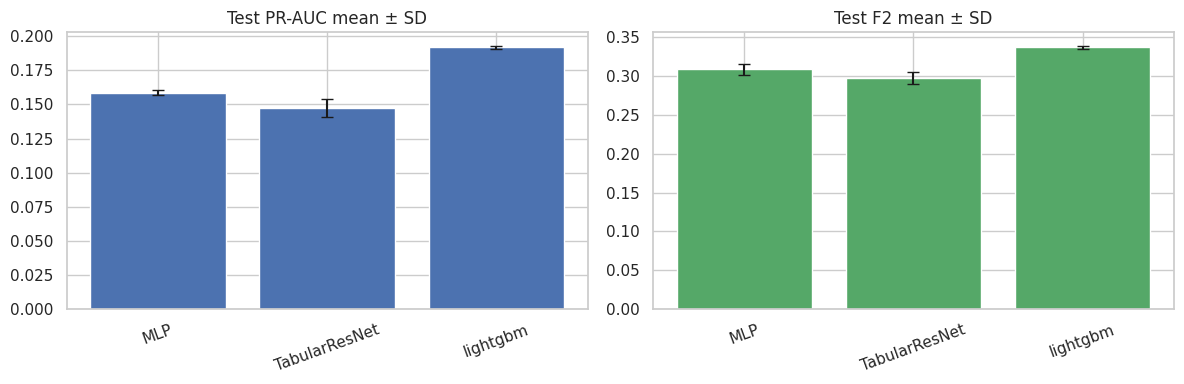

In [4]:
test_metrics = summary.query("split == 'test'").copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(test_metrics["model"], test_metrics["pr_auc_mean"], yerr=test_metrics["pr_auc_std"].fillna(0), color="#4C72B0", capsize=4)
axes[0].set_title("Test PR-AUC mean ± SD")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(test_metrics["model"], test_metrics["fbeta_mean"], yerr=test_metrics["fbeta_std"].fillna(0), color="#55A868", capsize=4)
axes[1].set_title("Test F2 mean ± SD")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(output_dir / "predictive_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

In [5]:
for seed, model_histories in result["histories"].items():
    for model_name, history in model_histories.items():
        display(Markdown(f"### {model_name} training history - seed {seed}"))
        display(pd.DataFrame(history))

### mlp training history - seed 42

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.261579,0.071550,0.000043
1,2.0,1.095087,0.093005,0.000050
2,3.0,1.041506,0.101111,0.000063
3,4.0,1.005775,0.105160,0.000082
4,5.0,0.992655,0.109034,0.000104
5,6.0,0.976863,0.112922,0.000132
6,7.0,0.965913,0.117161,0.000163
7,8.0,0.953369,0.119840,0.000199
8,9.0,0.944610,0.121843,0.000238
9,10.0,0.931156,0.124296,0.000280


### tabular_resnet training history - seed 42

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.076527,0.102762,0.000041
1,2.0,0.984723,0.110319,0.000045
2,3.0,0.961417,0.115613,0.000050
3,4.0,0.943719,0.120281,0.000059
4,5.0,0.930573,0.122504,0.000069
5,6.0,0.918418,0.123465,0.000082
6,7.0,0.917083,0.127108,0.000096
7,8.0,0.906432,0.127137,0.000113
8,9.0,0.894385,0.126735,0.000132
9,10.0,0.889799,0.128061,0.000152


### mlp training history - seed 123

...

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.131368,0.103897,0.000041
1,2.0,1.013255,0.109154,0.000045
2,3.0,0.979019,0.115420,0.000050
3,4.0,0.961361,0.122219,0.000059
4,5.0,0.942256,0.124893,0.000069
5,6.0,0.933218,0.129414,0.000082
6,7.0,0.925297,0.129564,0.000096
7,8.0,0.910268,0.127820,0.000113
8,9.0,0.905623,0.130897,0.000132
9,10.0,0.892994,0.132388,0.000152


### mlp training history - seed 2026

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.277714,0.071942,0.000043
1,2.0,1.087134,0.095408,0.000050
2,3.0,1.028956,0.103502,0.000063
3,4.0,0.999504,0.107705,0.000082
4,5.0,0.978850,0.112630,0.000104
5,6.0,0.969094,0.117242,0.000132
6,7.0,0.954381,0.122376,0.000163
7,8.0,0.947602,0.125444,0.000199
8,9.0,0.940019,0.127060,0.000238
9,10.0,0.932661,0.130460,0.000280


### tabular_resnet training history - seed 2026

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.138091,0.092566,0.000041
1,2.0,1.016767,0.104652,0.000045
2,3.0,0.978285,0.110549,0.000050
3,4.0,0.958752,0.112968,0.000059
4,5.0,0.943325,0.118426,0.000069
5,6.0,0.932471,0.122534,0.000082
6,7.0,0.927879,0.125434,0.000096
7,8.0,0.912197,0.126190,0.000113
8,9.0,0.903627,0.127506,0.000132
9,10.0,0.898638,0.129979,0.000152


## Takeaways

In [6]:
best = test_metrics.sort_values("pr_auc_mean", ascending=False).iloc[0]
display(Markdown(
    f"- Data source: **{', '.join(result['data_sources'])}**.\n"
    f"- Seeds: **{result['seeds']}**.\n"
    f"- Highest mean test PR-AUC: **{best['model']} = {best['pr_auc_mean']:.4f} ± {best['pr_auc_std']:.4f}**.\n"
    f"- Mean locked-threshold F2: **{best['fbeta_mean']:.4f} ± {best['fbeta_std']:.4f}**.\n"
    "- Interpret only real-data, non-quick runs as thesis evidence."
))

- Data source: **real**.
- Seeds: **[42, 123, 2026]**.
- Highest mean test PR-AUC: **lightgbm = 0.1921 ± 0.0011**.
- Mean locked-threshold F2: **0.3372 ± 0.0022**.
- Interpret only real-data, non-quick runs as thesis evidence.